In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path('../log/cache.csv')
df = pd.read_csv(csv_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values('iteration').reset_index(drop=True)

fitness_col = 'avg_fitness'
fitness_cols = [
    col for col in df.columns
    if col.endswith('_fitness') and col != fitness_col
]

numeric_cols = [
    fitness_col,
    *fitness_cols,
    'iteration',
    'populationSize',
    'generations',
    'newChromosomes',
    'mutator_child2_weight',
    'mutator_child2_p',
    'mutator_child2_numMutations',
    'mutator_child1_weight',
    'mutator_child1_p',
    'mutator_child1_numMutations',
    'general_MAX_CLUSTER_DISTANCE',
    'general_MAX_CLUSTER_JOIN_DISTANCE',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()


,iteration,timestamp,avg_fitness,general_MAX_CLUSTER_DISTANCE,general_MAX_CLUSTER_JOIN_DISTANCE,populationSize,generations,newChromosomes,eliminator_type,eliminator_elitism,...,crossover_child4_k,crossover_child4_p,crossover_child4_weight,crossover_child5_k,crossover_child5_p,crossover_child5_weight,selection_type,selection_tournamentSize,48xxx_random_constraints.job_fitness,51000_rijeka_random_constraints.job_fitness
0,1,2026-06-17 15:24:09.817278,64.624848,5.511144,15.099063,5000,2000,20,EliteEliminator,8,...,6,0.319196,0.615276,5,0.525631,0.350627,TournamentSelection,3,101.568046,27.681649
1,2,2026-06-17 15:34:18.902397,59.756477,10.211272,17.899675,200,8000,26,EliteEliminator,4,...,4,0.671720,0.252349,3,0.567840,0.545844,TournamentSelection,2,94.178730,25.334223
2,3,2026-06-17 15:35:04.985979,60.450161,5.893158,18.537005,50,2000,6,EliteEliminator,4,...,4,0.676526,0.727664,6,0.565126,0.538343,TournamentSelection,4,94.568332,26.331989
3,4,2026-06-17 15:55:45.598512,60.330663,9.936356,5.093688,500,8000,16,EliteEliminator,15,...,6,0.517491,0.628121,7,0.877371,0.932206,RankSelection,5,95.162162,25.499164
4,5,2026-06-17 16:07:07.088660,63.973171,9.795088,9.884525,500,5000,27,EliteGeometricEliminator,9,...,3,0.719553,0.950984,5,0.450206,0.589826,RankSelection,5,100.454602,27.491740


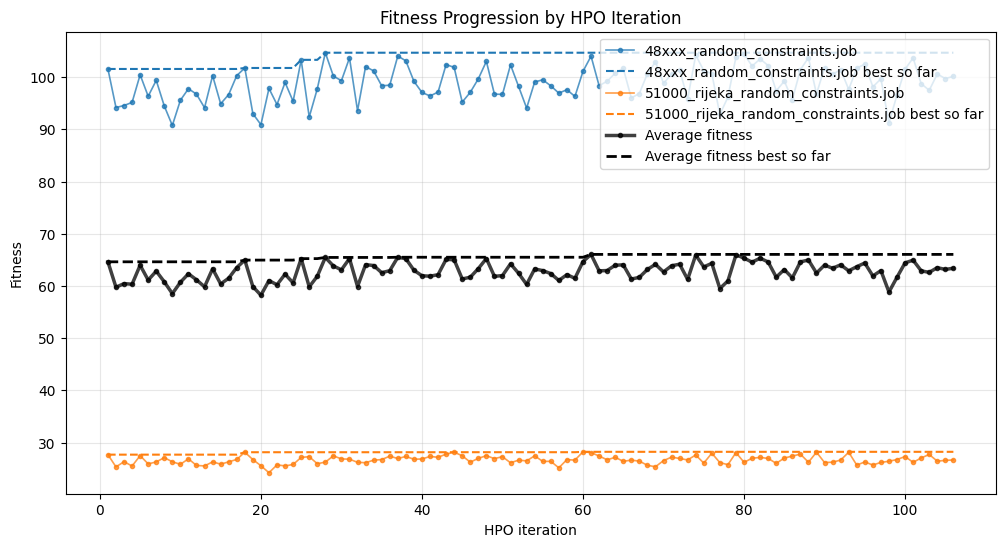

In [10]:
plt.figure(figsize=(12, 6))

fitness_plot_cols = [*fitness_cols, fitness_col]
fitness_labels = {
    fitness_col: 'Average fitness',
    **{col: col.replace('_fitness', '') for col in fitness_cols},
}

for col in fitness_plot_cols:
    label = fitness_labels[col]
    is_average = col == fitness_col
    line = plt.plot(
        df['iteration'],
        df[col],
        marker='o',
        markersize=3,
        linewidth=2.5 if is_average else 1.2,
        alpha=0.75,
        color='black' if is_average else None,
        label=label,
    )[0]
    plt.plot(
        df['iteration'],
        df[col].cummax(),
        linestyle='--',
        linewidth=2.0 if is_average else 1.5,
        color=line.get_color(),
        label=f'{label} best so far',
    )

plt.xlabel('HPO iteration')
plt.ylabel('Fitness')
plt.title('Fitness Progression by HPO Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


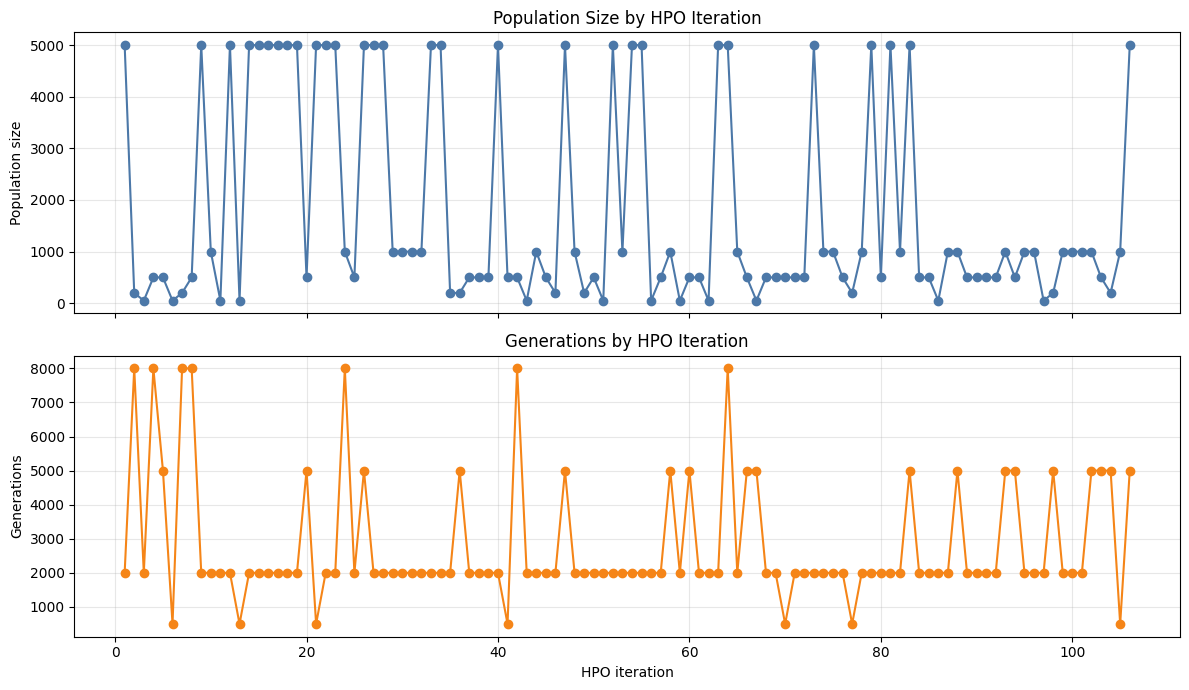

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df['iteration'], df['populationSize'], marker='o', linewidth=1.5, color='#4C78A8')
axes[0].set_ylabel('Population size')
axes[0].set_title('Population Size by HPO Iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['iteration'], df['generations'], marker='o', linewidth=1.5, color='#F58518')
axes[1].set_xlabel('HPO iteration')
axes[1].set_ylabel('Generations')
axes[1].set_title('Generations by HPO Iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


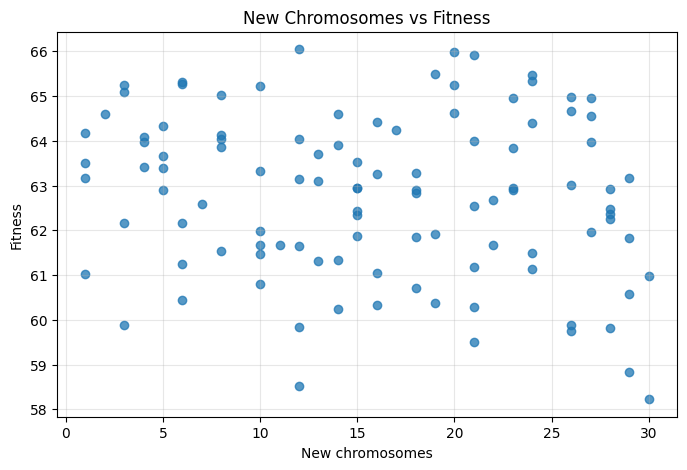

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df['newChromosomes'], df[fitness_col], alpha=0.75)
plt.xlabel('New chromosomes')
plt.ylabel('Fitness')
plt.title('New Chromosomes vs Fitness')
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_21092\2082958612.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(selection_data, labels=selection_order)


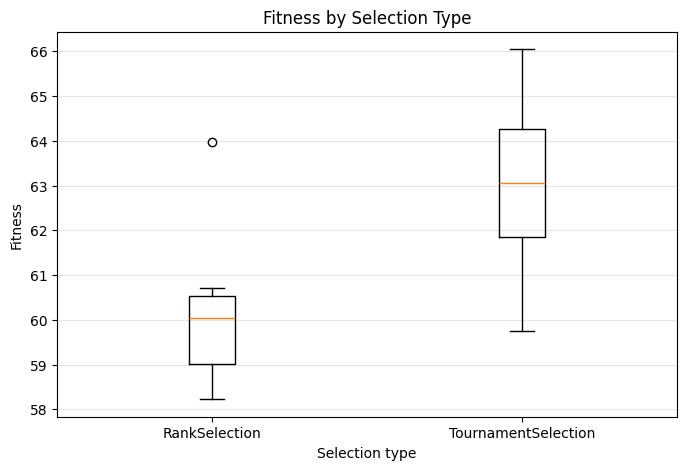

In [5]:
selection_order = sorted(df['selection_type'].dropna().unique())
selection_data = [
    df.loc[df['selection_type'] == selection_type, fitness_col].dropna()
    for selection_type in selection_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(selection_data, labels=selection_order)
plt.xlabel('Selection type')
plt.ylabel('Fitness')
plt.title('Fitness by Selection Type')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_21092\206297776.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(eliminator_data, labels=eliminator_order)


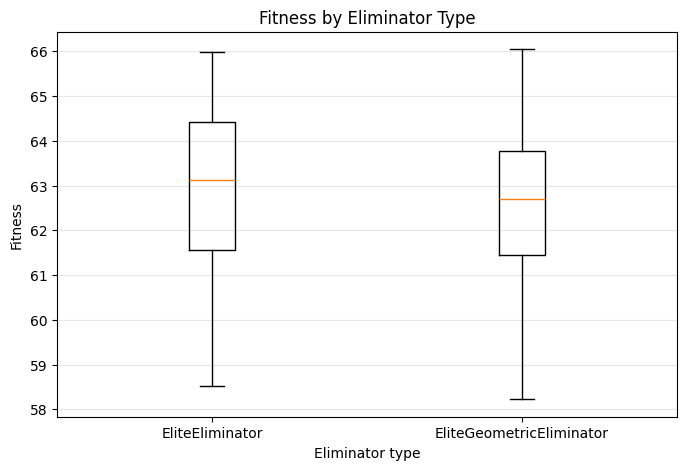

In [6]:
eliminator_order = sorted(df['eliminator_type'].dropna().unique())
eliminator_data = [
    df.loc[df['eliminator_type'] == eliminator_type, fitness_col].dropna()
    for eliminator_type in eliminator_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(eliminator_data, labels=eliminator_order)
plt.xlabel('Eliminator type')
plt.ylabel('Fitness')
plt.title('Fitness by Eliminator Type')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


,fitness_weighted_mean_weight,mean_weight,fitness_weighted_share
Geometric column crossover,0.675020,0.674546,0.235397
Geometric row crossover,0.618896,0.618859,0.215825
K-switch crossover,0.576053,0.576678,0.200884
Single-point crossover,0.509565,0.510260,0.177698
Column K-switch crossover,0.488052,0.488104,0.170196


C:\Users\stjep\AppData\Local\Temp\ipykernel_21092\689087610.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([weight_df[col].dropna() for col in weight_df.columns], labels=weight_df.columns)


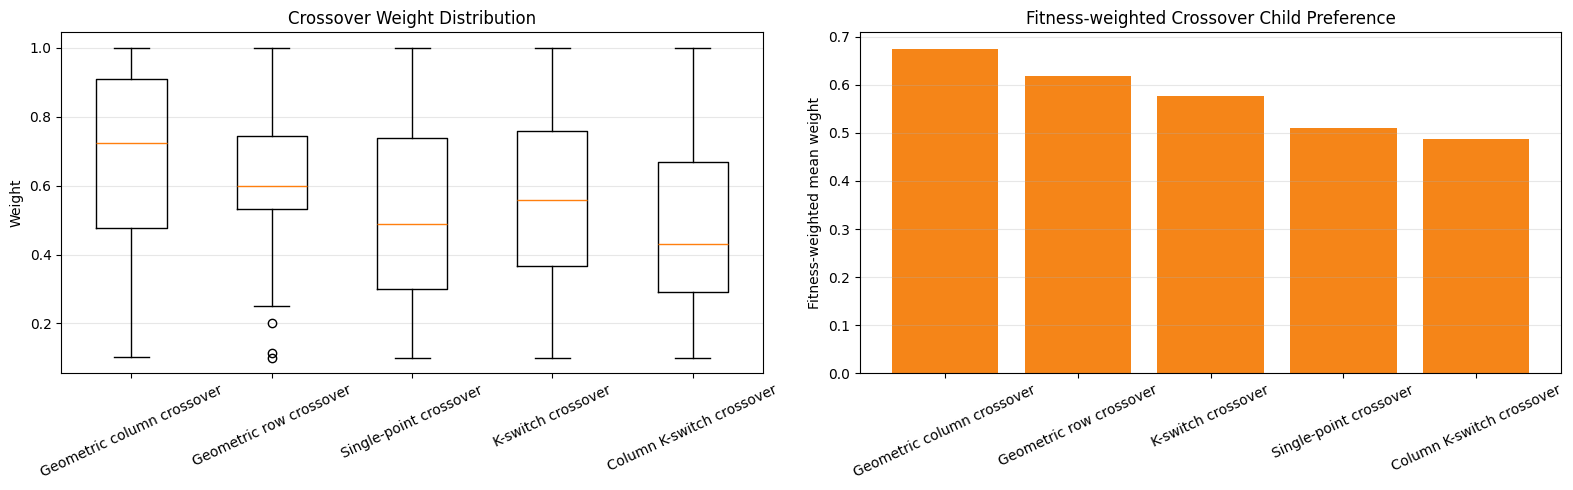

In [7]:
fitness = df[fitness_col]
total_fitness = fitness.sum()

child_weight_cols = {
    'crossover_child1_weight': 'Geometric column crossover',
    'crossover_child2_weight': 'Geometric row crossover',
    'crossover_child3_weight': 'Single-point crossover',
    'crossover_child4_weight': 'K-switch crossover',
    'crossover_child5_weight': 'Column K-switch crossover',
}

weight_df = df[list(child_weight_cols)].rename(columns=child_weight_cols)
summary = pd.DataFrame(
    {
        'fitness_weighted_mean_weight': {
            label: (df[col] * fitness).sum() / total_fitness
            for col, label in child_weight_cols.items()
        },
        'mean_weight': {
            label: df[col].mean()
            for col, label in child_weight_cols.items()
        },
    }
).sort_values('fitness_weighted_mean_weight', ascending=False)
summary['fitness_weighted_share'] = summary['fitness_weighted_mean_weight'] / summary['fitness_weighted_mean_weight'].sum()

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].boxplot([weight_df[col].dropna() for col in weight_df.columns], labels=weight_df.columns)
axes[0].set_ylabel('Weight')
axes[0].set_title('Crossover Weight Distribution')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(summary.index, summary['fitness_weighted_mean_weight'], color='#F58518')
axes[1].set_ylabel('Fitness-weighted mean weight')
axes[1].set_title('Fitness-weighted Crossover Child Preference')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


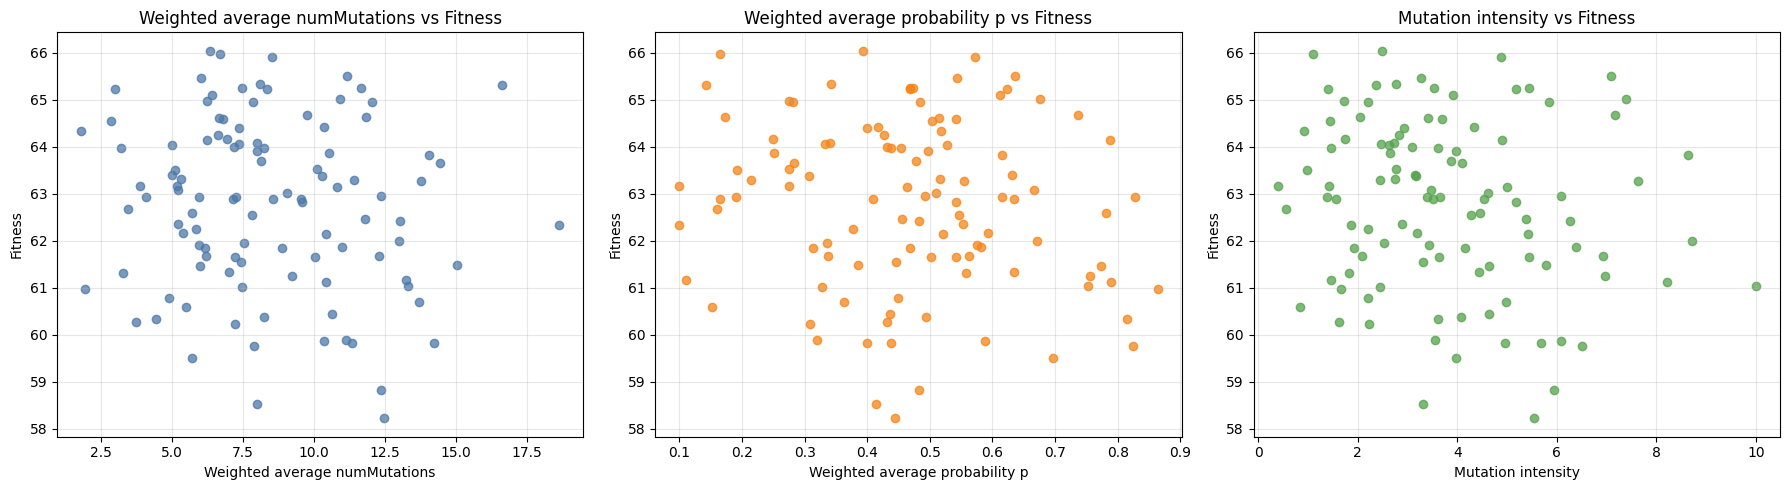

In [9]:
mutator_children = [
    {
        'label': 'Random simple mutator 1',
        'num_mutations': 'mutator_child1_numMutations',
        'probability': 'mutator_child1_p',
        'weight': 'mutator_child1_weight',
    },
    {
        'label': 'Random simple mutator 2',
        'num_mutations': 'mutator_child2_numMutations',
        'probability': 'mutator_child2_p',
        'weight': 'mutator_child2_weight',
    },
]

weight_cols = [child['weight'] for child in mutator_children]
weight_sum = df[weight_cols].sum(axis=1).replace(0, pd.NA)

mutator_analysis = pd.DataFrame(
    {
        'weighted_num_mutations': sum(
            df[child['num_mutations']] * df[child['weight']]
            for child in mutator_children
        ) / weight_sum,
        'weighted_probability': sum(
            df[child['probability']] * df[child['weight']]
            for child in mutator_children
        ) / weight_sum,
        fitness_col: df[fitness_col],
    }
).dropna()
mutator_analysis['mutation_intensity'] = (
    mutator_analysis['weighted_num_mutations']
    * mutator_analysis['weighted_probability']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ('weighted_num_mutations', 'Weighted average numMutations', '#4C78A8'),
    ('weighted_probability', 'Weighted average probability p', '#F58518'),
    ('mutation_intensity', 'Mutation intensity', '#54A24B'),
]

for ax, (column, xlabel, color) in zip(axes, plots):
    ax.scatter(mutator_analysis[column], mutator_analysis[fitness_col], alpha=0.75, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fitness')
    ax.set_title(f'{xlabel} vs Fitness')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
elite_df = df[df['eliminator_type'] == 'EliteEliminator'].dropna(subset=['eliminator_elitism', fitness_col])
geo_elite_df = df[df['eliminator_type'] == 'EliteGeometricEliminator'].dropna(subset=['eliminator_survivalRate', fitness_col])
tournament_df = df[df['selection_type'] == 'TournamentSelection'].dropna(subset=['selection_tournamentSize', fitness_col]).copy()
tournament_df['selection_tournamentSize'] = tournament_df['selection_tournamentSize'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(elite_df['eliminator_elitism'], elite_df[fitness_col], alpha=0.75, color='#4C78A8')
axes[0].set_xlabel('Elitism')
axes[0].set_ylabel('Fitness')
axes[0].set_title('EliteEliminator: Elitism vs Fitness')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(geo_elite_df['eliminator_survivalRate'], geo_elite_df[fitness_col], alpha=0.75, color='#F58518')
axes[1].set_xlabel('Survival rate')
axes[1].set_ylabel('Fitness')
axes[1].set_title('EliteGeometricEliminator: Survival Rate vs Fitness')
axes[1].grid(True, alpha=0.3)

tournament_order = sorted(tournament_df['selection_tournamentSize'].unique())
tournament_data = [
    tournament_df.loc[tournament_df['selection_tournamentSize'] == size, fitness_col]
    for size in tournament_order
]
axes[2].boxplot(tournament_data, labels=tournament_order)
axes[2].set_xlabel('Tournament size')
axes[2].set_ylabel('Fitness')
axes[2].set_title('TournamentSelection: Fitness by Tournament Size')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_21092\3004509799.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)
C:\Users\stjep\AppData\Local\Temp\ipykernel_21092\3004509799.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)


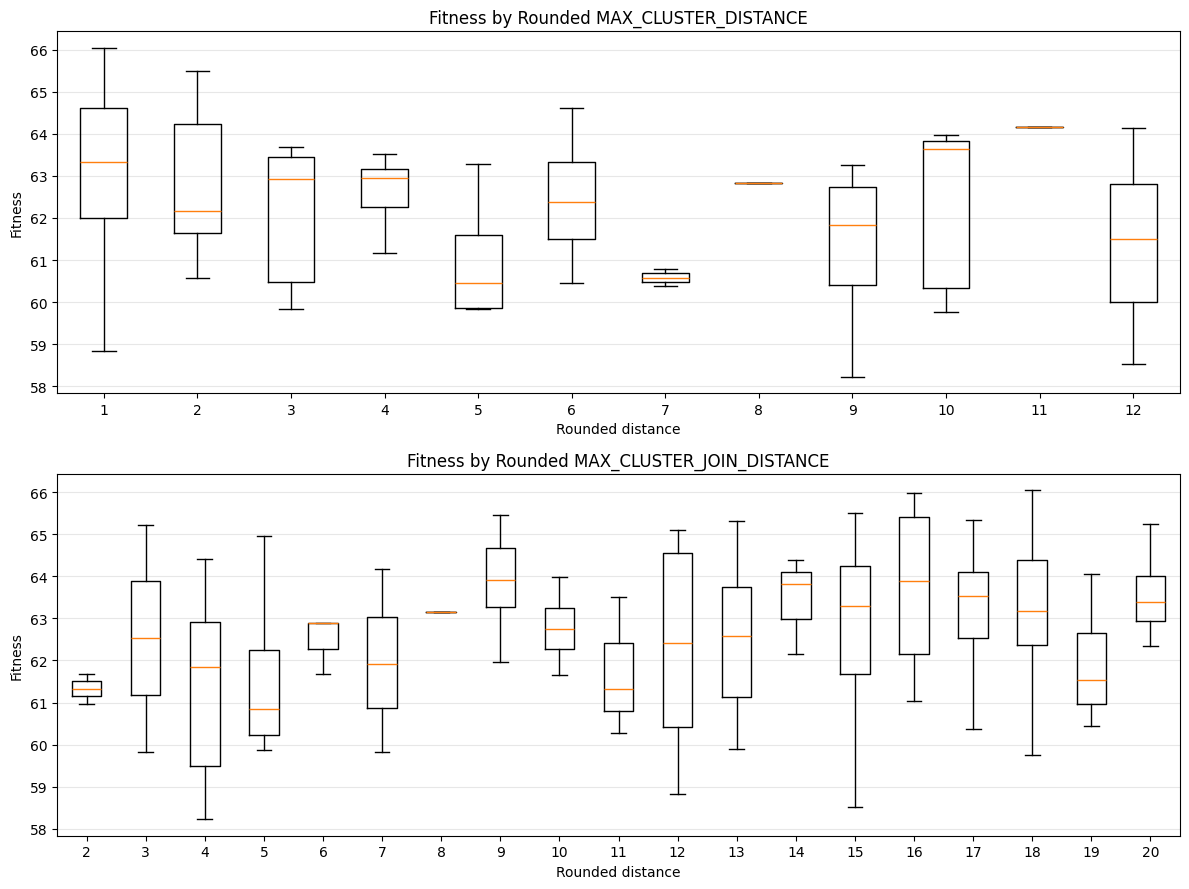

In [8]:
def plot_fitness_by_rounded_distance(ax, distance_col, title):
    plot_df = df[[distance_col, fitness_col]].dropna().copy()
    plot_df['rounded_distance'] = plot_df[distance_col].round().astype(int)
    order = sorted(plot_df['rounded_distance'].unique())
    data = [
        plot_df.loc[plot_df['rounded_distance'] == value, fitness_col]
        for value in order
    ]

    ax.boxplot(data, labels=order)
    ax.set_xlabel('Rounded distance')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_fitness_by_rounded_distance(
    axes[0],
    'general_MAX_CLUSTER_DISTANCE',
    'Fitness by Rounded MAX_CLUSTER_DISTANCE',
)
plot_fitness_by_rounded_distance(
    axes[1],
    'general_MAX_CLUSTER_JOIN_DISTANCE',
    'Fitness by Rounded MAX_CLUSTER_JOIN_DISTANCE',
)

plt.tight_layout()
plt.show()
